In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import logging

from einops import rearrange, repeat
from einops.layers.torch import Rearrange

import torch
import torch.nn as nn
from torch.nn import functional as F

from dalle2_pytorch import DiffusionPrior
from dalle2_pytorch.dalle2_pytorch import CausalTransformer, SinusoidalPosEmb, MLP

from brain_image.configs import get_device
from brain_image.model import NICEModel

logging.basicConfig(level=logging.INFO)

In [3]:
cp_path = "logs/nice/version_38/checkpoints/nice-epoch=24-val_top1_acc=0.3790.ckpt"
device = get_device()
dtype = torch.float16


In [4]:
# To get the ground truth image embeddings, we need to use the image encoder from huggingface

from brain_image.reconstruction import ReconstructionPipeline


pipe = ReconstructionPipeline.from_stable_diffusion(dtype=dtype, device=device)

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

An error occurred while trying to fetch /home/gasparyanartur/.cache/huggingface/hub/models--lambdalabs--sd-image-variations-diffusers/snapshots/a2a13984e57db80adcc9e3f85d568dcccb9b29fc/unet: Error no file named diffusion_pytorch_model.safetensors found in directory /home/gasparyanartur/.cache/huggingface/hub/models--lambdalabs--sd-image-variations-diffusers/snapshots/a2a13984e57db80adcc9e3f85d568dcccb9b29fc/unet.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
An error occurred while trying to fetch /home/gasparyanartur/.cache/huggingface/hub/models--lambdalabs--sd-image-variations-diffusers/snapshots/a2a13984e57db80adcc9e3f85d568dcccb9b29fc/vae: Error no file named diffusion_pytorch_model.safetensors found in directory /home/gasparyanartur/.cache/huggingface/hub/models--lambdalabs--sd-image-variations-diffusers/snapshots/a2a13984e57db80adcc9e3f85d568dcccb9b29fc/vae.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error

In [5]:
import random
from typing import cast

from torch import Size
import tqdm

from PIL.Image import Image


class DiffusionPriorNetwork(nn.Module):
    # Adapted from https://github.com/lucidrains/DALLE2-pytorch/blob/main/dalle2_pytorch/dalle2_pytorch.py

    def __init__(
        self,
        dim,
        num_timesteps: int | None = None,
        num_time_embeds: int = 1,
        num_image_embeds: int = 1,
        num_text_embeds: int = 1,
        max_text_len: int = 256,
        self_cond: bool = False,
        num_output_tokens: int = 256,
        **kwargs,
    ):
        super().__init__()
        self.dim = dim

        self.num_time_embeds = num_time_embeds
        self.num_image_embeds = num_image_embeds
        self.num_text_embeds = num_text_embeds

        self.to_text_embeds = nn.Sequential(
            (
                nn.Linear(dim, dim * num_text_embeds)
                if num_text_embeds > 1
                else nn.Identity()
            ),
            Rearrange("b (n d) -> b n d", n=num_text_embeds),
        )

        self.continuous_embedded_time = num_timesteps is None

        self.to_time_embeds = nn.Sequential(
            (
                nn.Embedding(num_timesteps, dim * num_time_embeds)
                if num_timesteps is not None
                else nn.Sequential(
                    SinusoidalPosEmb(dim), MLP(dim, dim * num_time_embeds)
                )
            ),  # also offer a continuous version of timestep embeddings, with a 2 layer MLP
            Rearrange("b (n d) -> b n d", n=num_time_embeds),
        )

        self.to_image_embeds = nn.Sequential(
            (
                nn.Linear(dim, dim * num_image_embeds)
                if num_image_embeds > 1
                else nn.Identity()
            ),
            Rearrange("b (n d) -> b n d", n=num_image_embeds),
        )

        self.learned_query = nn.Parameter(torch.randn(dim))
        self.causal_transformer = CausalTransformer(dim=dim, **kwargs)

        # dalle1 learned padding strategy

        self.max_text_len = max_text_len

        self.null_text_encodings = nn.Parameter(torch.randn(1, max_text_len, dim))
        self.null_text_embeds = nn.Parameter(torch.randn(1, num_text_embeds, dim))
        self.null_image_embed = nn.Parameter(torch.randn(1, dim))

        # whether to use self conditioning, Hinton's group's new ddpm technique

        self.self_cond = self_cond

        # Number of output tokens
        self.num_output_tokens = num_output_tokens

    def forward_with_cond_scale(self, *args, cond_scale=1.0, **kwargs):
        logits = self.forward(*args, **kwargs)

        if cond_scale == 1:
            return logits

        null_logits = self.forward(
            *args, text_cond_drop_prob=1.0, image_cond_drop_prob=1, **kwargs
        )
        return null_logits + (logits - null_logits) * cond_scale

    def _cond_drop_prob(
        self, prob: float, batch: int, device: torch.device, dtype: torch.dtype
    ) -> torch.Tensor:
        if prob == 0.0:
            p = torch.ones((batch,), device=device, dtype=dtype)
        elif prob == 1.0:
            p = torch.zeros((batch,), device=device, dtype=dtype)
        else:
            p = torch.rand((batch,), device=device, dtype=dtype) < 1 - prob
        return p.bool()

    def forward(
        self,
        image_embed: torch.Tensor,
        diffusion_timesteps: torch.Tensor,
        *,
        text_embed: torch.Tensor | None = None,
        text_encodings: torch.Tensor | None = None,
        self_cond: torch.Tensor | None = None,
        text_cond_drop_prob: float=0.0,
        image_cond_drop_prob=0.0,
    ):
        batch, dim, device, dtype = (
            *image_embed.shape,
            image_embed.device,
            image_embed.dtype,
        )

        # setup self conditioning

        if self.self_cond:
            self_cond = self_cond or torch.zeros(
                batch, self.dim, device=device, dtype=dtype
            )
            self_cond = rearrange(self_cond, "b d -> b 1 d")

        # in section 2.2, last paragraph
        # "... consisting of encoded text, CLIP text embedding, diffusion timestep embedding, noised CLIP image embedding, final embedding for prediction"

        text_embed = self.to_text_embeds(text_embed)
        image_embed = self.to_image_embeds(image_embed)

        # classifier free guidance masks
        text_keep_mask = self._cond_drop_prob(text_cond_drop_prob, batch, device, dtype)
        text_keep_mask = rearrange(text_keep_mask, "b -> b 1 1")

        image_keep_mask = self._cond_drop_prob(
            image_cond_drop_prob, batch, device, dtype
        )
        image_keep_mask = rearrange(image_keep_mask, "b -> b 1 1")

        # make text encodings optional
        # although the paper seems to suggest it is present <--

        if text_encodings is None:
            text_encodings = torch.empty((batch, 0, dim), device=device, dtype=dtype)

        mask = torch.any(text_encodings != 0.0, dim=-1)

        # replace any padding in the text encodings with learned padding tokens unique across position

        text_encodings = text_encodings[:, : self.max_text_len]
        mask = mask[:, : self.max_text_len]

        text_len = text_encodings.shape[-2]
        remainder = self.max_text_len - text_len

        if remainder > 0:
            text_encodings = F.pad(text_encodings, (0, 0, 0, remainder), value=0.0)
            mask = F.pad(mask, (0, remainder), value=False)

        # mask out text encodings with null encodings

        null_text_encodings = self.null_text_encodings.to(text_encodings.dtype)

        text_encodings = torch.where(
            rearrange(mask, "b n -> b n 1").clone() & text_keep_mask,
            text_encodings,
            null_text_encodings,
        )

        # mask out text embeddings with null text embeddings

        null_text_embeds = self.null_text_embeds.to(text_embed.dtype)

        text_embed = torch.where(text_keep_mask, text_embed, null_text_embeds)

        # mask out image embeddings with null image embeddings

        null_image_embed = self.null_image_embed.to(image_embed.dtype)

        image_embed = torch.where(image_keep_mask, image_embed, null_image_embed)

        # whether text embedding is used for conditioning depends on whether text encodings are available for attention (for classifier free guidance, even though it seems from the paper it was not used in the prior ddpm, as the objective is different)
        # but let's just do it right

        if self.continuous_embedded_time:
            diffusion_timesteps = diffusion_timesteps.type(dtype)

        time_embed = self.to_time_embeds(diffusion_timesteps)

        learned_queries = repeat(self.learned_query, "d -> b 1 d", b=batch)

        if self.self_cond:
            learned_queries = torch.cat((self_cond, learned_queries), dim=-2)

        tokens = torch.cat(
            (text_encodings, text_embed, time_embed, image_embed, learned_queries),
            dim=-2,
        )

        # attend

        tokens = self.causal_transformer(tokens)

        # get learned query, which should predict the image embedding (per DDPM timestep)

        pred_image_embed = tokens[..., -1, :]

        return pred_image_embed


class BrainDiffusionPrior(DiffusionPrior):
    # Adapted from https://github.com/medarc-ai/fmri-reconstruction-nsd/blob/main/src/models.py#l232

    def __init__(
        self, net: DiffusionPriorNetwork, *args, **kwargs
    ):
        super().__init__(net=net, *args, **kwargs)
        self.net = net

    @torch.no_grad()
    def p_sample(
        self,
        x: torch.Tensor,
        t: torch.Tensor,
        text_cond: dict | None = None,
        self_cond: torch.Tensor | None = None,
        clip_denoised: bool=True,
        cond_scale: float=1.0,
        generator: torch.Generator | None = None,
    ):
        b = x.shape[0]
        model_mean, _, model_log_variance, x_start = self.p_mean_variance(
            x=x,
            t=t,
            text_cond=text_cond,
            self_cond=self_cond,
            clip_denoised=clip_denoised,
            cond_scale=cond_scale,
        )
        noise = torch.randn(
            x.size(), device=x.device, dtype=x.dtype, generator=generator
        )
        # no noise when t == 0
        nonzero_mask = (1 - (t == 0).float()).reshape(b, *((1,) * (len(x.shape) - 1)))
        pred = model_mean + nonzero_mask * (0.5 * model_log_variance).exp() * noise
        return pred, x_start

    @torch.no_grad()
    def p_sample_loop_ddpm(
        self, shape: Size, text_cond: dict, cond_scale: float=1.0, generator: torch.Generator | None = None, progress_bar: bool = False
    ):
        batch = shape[0]
        device = cast(torch.device, self.device)

        if generator is None:
            image_embed = torch.randn(shape, device=device)
        else:
            image_embed = torch.randn(shape, device=device, generator=generator)

        x_start = None  # for self-conditioning

        if self.init_image_embed_l2norm:
            image_embed = image_embed.norm(dim=-1) * cast(float, self.image_embed_scale)

        for i in tqdm.tqdm(
            reversed(range(0, self.noise_scheduler.num_timesteps)),
            desc=f"DDPM sampling: {self.net.num_timesteps} timesteps",
            total=self.noise_scheduler.num_timesteps,
            disable=not progress_bar,
        ):
            times = torch.full((batch,), i, device=device, dtype=torch.long)

            self_cond = x_start if self.net.self_cond else None
            image_embed, x_start = self.p_sample(
                image_embed,
                times,
                text_cond=text_cond,
                self_cond=self_cond,
                cond_scale=cond_scale,
                generator=generator,
            )

        if self.sampling_final_clamp_l2norm and self.predict_x_start:
            image_embed = self.l2norm_clamp_embed(image_embed)

        return image_embed

    def p_losses(self, image_embed: torch.Tensor, times: torch.Tensor, text_cond: dict, noise: torch.Tensor | None = None) -> tuple[torch.Tensor, torch.Tensor]:
        noise = noise or torch.randn_like(image_embed)

        image_embed_noisy = self.noise_scheduler.q_sample(
            x_start=image_embed, t=times, noise=noise
        )

        self_cond = None
        if self.net.self_cond and random.random() < 0.5:
            with torch.no_grad():
                self_cond = self.net(image_embed_noisy, times, **text_cond).detach()

        pred = self.net(
            image_embed_noisy,
            times,
            self_cond=self_cond,
            text_cond_drop_prob=self.text_cond_drop_prob,
            image_cond_drop_prob=self.image_cond_drop_prob,
            **text_cond,
        )

        if self.predict_x_start and self.training_clamp_l2norm:
            pred = self.l2norm_clamp_embed(pred)

        if self.predict_v:
            target = self.noise_scheduler.calculate_v(image_embed, times, noise)
        elif self.predict_x_start:
            target = image_embed
        else:
            target = noise

        loss = self.noise_scheduler.loss_fn(pred, target)
        return loss, pred

    def forward(
        self,
        text: str | None = None,
        image: Image | None = None,
        brain_embedding: torch.Tensor | None = None,
        text_embedding: torch.Tensor | None = None,  # allow for training on preprocessed CLIP text and image embeddings
        image_embedding: torch.Tensor | None = None,
        text_encodings: torch.Tensor | None = None,  # as well as CLIP text encodings
        *args,
        **kwargs,
    ):
        # Validate inputs
        assert (
            (text is not None) or (text_embedding is not None) or (brain_embedding is not None)
        ), "either text, text embedding, or voxel must be supplied"

        if text is not None or image is not None:
            logging.warning("Text or image was passed in. Using clip to embed text and image. This part of the code may not be tested properly.")
            assert self.clip is not None, "clip must be trained if you wish to pass in text or image"

        assert (image is not None) or (image_embedding is not None), "either image or image embedding must be supplied"
        assert not (
            self.condition_on_text_encodings
            and (text_encodings is None and text is None)
        ), "text encodings must be present if you specified you wish to condition on it on initialization"

        if brain_embedding is not None:
            if text_embedding is not None:
                logging.warning("Both text embedding and brain embedding were passed in. Using brain embedding.")

            text_embedding = brain_embedding

        if image is not None:
            image_embedding, _ = self.clip.embed_image(image) # type: ignore

        # calculate text conditionings, based on what is passed in

        if text is not None:
            text_embedding, text_encodings = self.clip.embed_text(text) # type: ignore

        text_cond = dict(text_embed=text_embedding)


        if self.condition_on_text_encodings:
            assert text_encodings is not None, "text encodings must be present for diffusion prior if specified"
            text_cond = {**text_cond, "text_encodings": text_encodings}


        # Setup diffusion 

        assert image_embedding is not None, "image embedding must be present"
        assert text_embedding is not None, "text embedding must be present"

        # timestep conditioning from ddpm

        batch, device = image_embedding.shape[0], image_embedding.device
        times = self.noise_scheduler.sample_random_times(batch)

        image_embedding *= cast(float, self.image_embed_scale)

        # calculate forward loss

        loss, pred = self.p_losses(
            image_embedding, times, text_cond=text_cond, *args, **kwargs
        )

        return loss, pred  # , text_embed


logging.basicConfig(level=logging.INFO)

nice_model = NICEModel.load_checkpoint(cp_path, compile=False).to(device, dtype=dtype)


print(nice_model.config.project_dim)

net = DiffusionPriorNetwork(
    dim=nice_model.config.project_dim,
    num_timesteps=1000,
    num_time_embeds=1,
    num_image_embeds=1,
    num_text_embeds=1,
    max_text_len=nice_model.config.project_dim,
    self_cond=False,
    num_output_tokens=nice_model.config.project_dim,
    depth=6,
)
net.to(device, dtype=dtype)

prior = BrainDiffusionPrior(
    net=net,
    image_embed_dim=nice_model.config.project_dim,
    condition_on_text_encodings=False,
)

prior.eval()

prior.to(device, dtype=dtype)

768


BrainDiffusionPrior(
  (noise_scheduler): NoiseScheduler()
  (net): DiffusionPriorNetwork(
    (to_text_embeds): Sequential(
      (0): Identity()
      (1): Rearrange('b (n d) -> b n d', n=1)
    )
    (to_time_embeds): Sequential(
      (0): Embedding(1000, 768)
      (1): Rearrange('b (n d) -> b n d', n=1)
    )
    (to_image_embeds): Sequential(
      (0): Identity()
      (1): Rearrange('b (n d) -> b n d', n=1)
    )
    (causal_transformer): CausalTransformer(
      (init_norm): Identity()
      (rel_pos_bias): RelPosBias(
        (relative_attention_bias): Embedding(32, 8)
      )
      (layers): ModuleList(
        (0-5): 6 x ModuleList(
          (0): Attention(
            (norm): LayerNorm()
            (dropout): Dropout(p=0.0, inplace=False)
            (to_q): Linear(in_features=768, out_features=512, bias=False)
            (to_kv): Linear(in_features=768, out_features=128, bias=False)
            (rotary_emb): RotaryEmbedding()
            (to_out): Sequential(
        

In [ ]:
from pathlib import Path
from brain_image.data import load_image_from_path


batch_size = 4

loader = nice_model.data_module.test_dataloader()
ex_batch = next(iter(loader))
img_latent = ex_batch["img_latent"][:batch_size].to(device, dtype=dtype)
eeg_data = ex_batch["eeg_data"][:batch_size].to(device, dtype=dtype)
img_path = ex_batch["img_path"][:batch_size]

images = torch.stack([load_image_from_path(Path(p)) for p in img_path])[:batch_size].to(device, dtype=dtype)

with torch.no_grad():

    img_latent = pipe.encode_conditioning_image(images)
    
    # Brain embed
    eeg_embed = nice_model.eeg_encoder(eeg_data)
    eeg_proj = nice_model.eeg_projector(eeg_embed).to(device)

    prior_loss, prior_pred = prior.forward(brain_embedding=eeg_proj, image_embedding=img_latent)

    latent_reconstructed = pipe.reconstruct_latents(prior_pred)

/home/gasparyanartur/dev/brain-image-implementation/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:626: UserWarning: This DataLoader will create 32 worker processes in total. Our suggested max number of worker in current system is 12, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


torch.Size([4, 768])
torch.Size([4, 768])
torch.Size([4, 768])
torch.Size([4, 768])


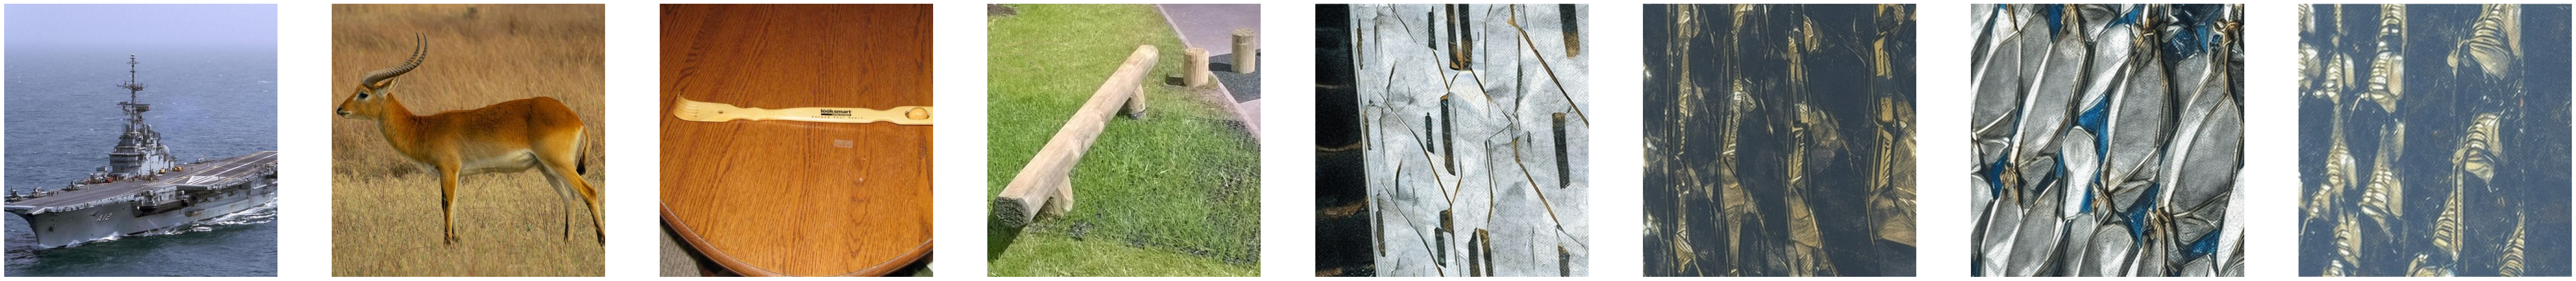

In [7]:
from brain_image.utils import show_image


show_image(images, latent_reconstructed, transforms=["normalize"] * batch_size + ["none"] * batch_size)